<a href="https://colab.research.google.com/github/azar79/clase-de-inteligencia-artificial-/blob/main/Copia_de_asignacion_2_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descripción del data set Financial data of 4400+ public companies

✅ ¿Qué es?

Se trata de un conjunto de datos que contiene información financiera de más de 4 400 empresas públicas.  

Los datos fueron raspados (“scraped”) de Yahoo Finance, lo que incluye los estados financieros — el balance general (“balance sheet”), el estado de resultados (“income statement”), y el flujo de caja (“cash flow statement”).  

Incluye datos tanto anuales como trimestrales para un período reciente (aproximadamente los últimos 4 años) para cada empresa.  


# ¿Qué contiene exactamente?

Algunas de las características clave de la base de datos:

- Cada empresa viene identificada con su ticker o símbolo bursátil (o equivalente) y posiblemente con su nombre, industria, etc.
- Para cada empresa, los datos incluyen:
    - Estado de resultados: ingresos, beneficios, gastos, etc.
    - Balance general: activos, pasivos, capital contable, etc.
    - Flujo de caja: flujos operativos, de inversión, de financiación, etc.
- Los datos están organizados para que puedas ver la evolución por trimestre y por año, lo que permite análisis de tendencias.
- Se pueden usar variables financieras como predictors (por ejemplo: activos, pasivos, ingresos) y variables objetivo como beneficio, rentabilidad, crecimiento, etc.

# Paso 1 — Reconocer el dataset

1. Objetivo: investigar el dataset entregado en la asignación 2, revisar el nombre de cada columna y documentar qué representa cada una (tipo, unidad, periodicidad, observaciones).

2. Pasos recomendados:
    - Cargar el archivo entregado (por ejemplo: df = pd.read_csv(...)) y listar columnas: df.columns
    - Para cada columna: buscar su significado (glosario, documentación de la fuente, o inspección de valores).
    - Anotar tipo de dato, unidad (USD, porcentaje, entero), periodicidad (trimestral/anual) y cualquier observación (por ejemplo: calculada, acumulada, neta/bruta).
    - Generar la lista final con nombre y descripción clara y breve.

3. Ejemplo de Plantilla para la lista (reemplazar con las columnas reales del dataset):

- ticker: Identificador bursátil de la empresa (string). Ejemplo: "AAPL".
- fiscal_date: Fecha del periodo financiero (YYYY-MM-DD). Indica el cierre del trimestre/año.
- revenue: Ingresos netos durante el periodo (num, USD). Periodicidad: trimestral/anual.
- gross_profit: Beneficio bruto (num, USD). Definición: ingresos menos costo de ventas.
- operating_income: Resultado operativo (num, USD). Incluye gastos operativos.
- net_income: Beneficio neto después de impuestos (num, USD).


4. Resultado esperado:
    - Un listado documentado con cada columna del dataset y su descripción (puede entregarse como tabla o como lista de pares nombre→descripción).

In [5]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to your CSV file in Google Drive
# IMPORTANT: You need to replace 'path/to/your/financial_data.csv' with the actual path
# For example: '/content/drive/MyDrive/financial_data.csv'
file_path = '/content/balanceSheetHistory_annually (1).csv'

try:
    df = pd.read_csv(file_path)
    print('Dataset loaded successfully!')
    print(f'Number of rows: {len(df)}')
    print(f'Number of columns: {len(df.columns)}')
    display(df.head())
except FileNotFoundError:
    print(f'Error: The file {file_path} not found. Please upload the correct CSV file or specify its path in Google Drive.')
    print('Make sure the file path is correct after mounting your Google Drive.')
except Exception as e:
    print(f'An error occurred: {e}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Number of rows: 17511
Number of columns: 31


,stock,endDate,accountsPayable,inventory,longTermDebt,netReceivables,netTangibleAssets,longTermInvestments,totalCurrentAssets,propertyPlantEquipment,...,totalAssets,otherCurrentLiab,deferredLongTermLiab,totalStockholderEquity,totalLiab,capitalSurplus,intangibleAssets,shortTermInvestments,shortLongTermDebt,minorityInterest
0,IVC,2019-12-31,88003000.0,121184000.0,219464000.0,140013000.0,-91334000.0,85000.0,355877000.0,92183000.0,...,8.521260e+08,21634000.0,602000.0,308516000.0,543610000.0,312650000.0,26447000.0,NaN,NaN,NaN
1,IVC,2018-12-31,92469000.0,128644000.0,225733000.0,138476000.0,-48632000.0,90000.0,397410000.0,74306000.0,...,8.858550e+08,22750000.0,402000.0,359147000.0,526708000.0,297919000.0,26506000.0,NaN,NaN,NaN
2,IVC,2017-12-31,90566000.0,121933000.0,241405000.0,143464000.0,-8233000.0,103000.0,456914000.0,80016000.0,...,1.066033e+09,34119000.0,787000.0,423294000.0,642739000.0,290125000.0,30244000.0,NaN,NaN,NaN
3,IVC,2016-12-31,88236000.0,135644000.0,146088000.0,132707000.0,32762000.0,108000.0,409072000.0,75359000.0,...,9.037430e+08,33800000.0,793000.0,422387000.0,481356000.0,266151000.0,29023000.0,NaN,NaN,NaN
4,CSLT,2019-12-31,19596000.0,NaN,NaN,31397000.0,68911000.0,NaN,95470000.0,18762000.0,...,2.427840e+08,18768000.0,21429000.0,172874000.0,69910000.0,627899000.0,NaN,16411000.0,NaN,NaN


In [6]:
# Display column names and their data types to start documenting them as per Paso 1, item 2.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17511 entries, 0 to 17510
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   stock                         17511 non-null  object 
 1   endDate                       17511 non-null  object 
 2   accountsPayable               16415 non-null  float64
 3   inventory                     9640 non-null   float64
 4   longTermDebt                  11222 non-null  float64
 5   netReceivables                14544 non-null  float64
 6   netTangibleAssets             17351 non-null  float64
 7   longTermInvestments           7499 non-null   float64
 8   totalCurrentAssets            17331 non-null  float64
 9   propertyPlantEquipment        15768 non-null  float64
 10  otherStockholderEquity        12046 non-null  float64
 11  deferredLongTermAssetCharges  6055 non-null   float64
 12  totalCurrentLiabilities       17316 non-null  float64
 13  c

In [7]:
# Display descriptive statistics for numerical columns
display(df.describe())

,accountsPayable,inventory,longTermDebt,netReceivables,netTangibleAssets,longTermInvestments,totalCurrentAssets,propertyPlantEquipment,otherStockholderEquity,deferredLongTermAssetCharges,...,totalAssets,otherCurrentLiab,deferredLongTermLiab,totalStockholderEquity,totalLiab,capitalSurplus,intangibleAssets,shortTermInvestments,shortLongTermDebt,minorityInterest
count,1.641500e+04,9.640000e+03,1.122200e+04,1.454400e+04,1.735100e+04,7.499000e+03,1.733100e+04,1.576800e+04,1.204600e+04,6.055000e+03,...,1.733900e+04,1.330400e+04,2.632000e+03,1.735400e+04,1.732600e+04,1.448900e+04,1.123800e+04,3.858000e+03,5.435000e+03,4.405000e+03
mean,3.431181e+09,5.397221e+08,3.464196e+09,9.128711e+08,9.131987e+08,4.354567e+09,3.544844e+09,2.075143e+09,-2.280976e+08,2.590617e+08,...,1.197869e+10,8.246799e+08,2.740772e+08,2.517428e+09,9.261290e+09,1.684475e+09,9.852217e+08,3.164886e+09,5.751461e+08,5.237217e+08
std,4.864555e+10,2.193146e+09,1.410168e+10,5.844426e+09,9.562153e+09,2.921496e+10,3.534564e+10,9.406400e+09,1.744640e+09,1.487030e+09,...,8.792659e+10,6.643297e+09,1.107033e+09,1.137989e+10,7.836466e+10,5.764215e+09,5.116375e+09,2.664274e+10,5.544788e+09,2.640750e+09
min,8.800000e+01,3.000000e+03,1.282000e+03,3.500000e+01,-1.261080e+11,1.000000e+00,8.200000e+01,7.000000e+00,-3.717000e+10,3.000000e+03,...,8.200000e+01,-1.110000e+08,2.953000e+03,-1.268800e+10,1.833000e+03,1.000000e+01,7.480000e+02,-3.490000e+02,-1.490000e+05,-3.988000e+09
25%,4.955000e+06,7.293750e+06,1.014895e+08,1.188575e+07,1.864948e+06,3.018300e+07,5.356650e+07,1.221242e+07,-7.899000e+07,4.165000e+06,...,1.818925e+08,4.651250e+06,2.400000e+06,5.855725e+07,6.004275e+07,1.050929e+08,8.894750e+06,1.152803e+07,4.500000e+06,3.182000e+06
50%,3.883900e+07,5.148450e+07,5.471190e+08,7.444950e+07,1.115000e+08,1.716000e+08,2.290220e+08,1.024635e+08,-5.967500e+06,1.775000e+07,...,1.043376e+09,2.990850e+07,8.867074e+06,3.191600e+08,5.313730e+08,3.387450e+08,6.019100e+07,6.301800e+07,2.300000e+07,3.040000e+07
75%,2.861095e+08,2.978500e+08,2.126692e+09,3.557384e+08,5.735550e+08,8.299700e+08,9.501485e+08,7.545180e+08,-4.107375e+04,8.100000e+07,...,4.291116e+09,1.621028e+08,6.544650e+07,1.273124e+09,2.758480e+09,1.114546e+09,3.333772e+08,2.719810e+08,1.320755e+08,1.850000e+08
max,1.635858e+12,7.662200e+10,3.342920e+11,1.882320e+11,1.917940e+11,5.452370e+11,1.181001e+12,2.596510e+11,3.381500e+10,5.119400e+10,...,2.715152e+12,2.314230e+11,1.504700e+10,2.448230e+11,2.522484e+12,1.262790e+11,1.638270e+11,5.957710e+11,2.272960e+11,8.183300e+10


In [ ]:
#codigo aqui

# Paso 2 — Seleccionar columnas relevantes

Después de haber cargado el dataset, elimina todas las columnas y quédate solo con: `stock`, `endDate` y `cash`.

- Verifica que los nombres y la capitalización de las columnas sean correctos antes de seleccionar.


In [8]:
# Select only the relevant columns: stock, endDate, and cash as per Paso 2.
df_selected = df[['stock', 'endDate', 'cash']].copy()

print(f'DataFrame after selecting columns: {df_selected.shape[1]} columns')
print(df_selected.info())
display(df_selected.head())

DataFrame after selecting columns: 3 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17511 entries, 0 to 17510
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   stock    17511 non-null  object 
 1   endDate  17511 non-null  object 
 2   cash     16929 non-null  float64
dtypes: float64(1), object(2)
memory usage: 410.5+ KB
None


,stock,endDate,cash
0,IVC,2019-12-31,80063000.0
1,IVC,2018-12-31,116907000.0
2,IVC,2017-12-31,176528000.0
3,IVC,2016-12-31,124234000.0
4,CSLT,2019-12-31,43017000.0


# Paso 3 — Separar por empresas y elegir 3 para predecir su cantidad de dinero por fecha

- Objetivo: crear series temporales por empresa usando las columnas `stock`, `endDate` y `cash` y seleccionar 3 empresas para modelar y predecir `cash` por fecha.
- Pasos recomendados:
    - Verificar que las columnas `stock`, `endDate` y `cash` existen y están limpias (sin valores nulos o con imputación cuando sea necesario).
    - Ordenar el dataframe por `stock` y `endDate` (ascendente) para obtener la serie temporal de cada empresa.
    - Agrupar por `stock` y crear un subset por empresa.
    - Elegir 3 empresas con suficientes observaciones (p. ej. mayor número de fechas disponibles o relevancia del negocio).
    - Para cada empresa seleccionada, preparar los datos de entrenamiento/validación (features temporales, ventanas, lag, etc.) y definir la variable objetivo `cash` por `endDate`.

In [16]:
# Paso 3 — Separar por empresas y elegir 3 para predecir su cantidad de dinero por fecha

# 1. Verificar que las columnas 'stock', 'endDate' y 'cash' existen y están limpias
# (Manejar valores nulos en 'cash')
df_processed = df_selected.dropna(subset=['cash']).copy()
print(f"DataFrame after dropping rows with null cash values: {len(df_processed)} rows")

# 2. Convertir 'endDate' a tipo fecha
df_processed['endDate'] = pd.to_datetime(df_processed['endDate'])
print(df_processed.info())

# 3. Ordenar el dataframe por 'stock' y 'endDate' (ascendente)
df_processed = df_processed.sort_values(by=['stock', 'endDate']).reset_index(drop=True)

# Añadir la 'lag feature' para 'cash' (valor del período anterior)
df_processed['cash_lag_1'] = df_processed.groupby('stock')['cash'].shift(1)

# Eliminar filas donde 'cash_lag_1' es NaN (la primera observación de cada stock)
df_processed.dropna(subset=['cash_lag_1'], inplace=True)
df_processed.reset_index(drop=True, inplace=True)

print("DataFrame sorted by 'stock' and 'endDate' with lag feature:")
display(df_processed.head())

# 4. Agrupar por 'stock' y elegir 3 empresas con suficientes observaciones
stock_counts = df_processed['stock'].value_counts()
print(f'Total unique stocks: {len(stock_counts)}')
print('Top 10 stocks by number of records:')
display(stock_counts.head(10))

# Seleccionamos las 3 empresas con más datos (asegurarse de que estén en df_processed después de dropear NaNs)
top_3_stocks = stock_counts.head(3).index.tolist()
print(f'Selected top 3 stocks for prediction: {top_3_stocks}')

# Filtramos df_processed para solo las 3 empresas seleccionadas
df_selected_companies = df_processed[df_processed['stock'].isin(top_3_stocks)].copy()

# Opcional: Crear un diccionario de DataFrames por empresa si es necesario
# companies_data = {stock: df_processed[df_processed['stock'] == stock].copy() for stock in top_3_stocks}
# for stock, data in companies_data.items():
#     print(f'\nData for {stock}:')
#     display(data.head())

DataFrame after dropping rows with null cash values: 16929 rows
<class 'pandas.core.frame.DataFrame'>
Index: 16929 entries, 0 to 17510
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   stock    16929 non-null  object        
 1   endDate  16929 non-null  datetime64[ns]
 2   cash     16929 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 529.0+ KB
None
DataFrame sorted by 'stock' and 'endDate' with lag feature:


,stock,endDate,cash,cash_lag_1
0,A,2017-10-31,2.678000e+09,2.289000e+09
1,A,2018-10-31,2.247000e+09,2.678000e+09
2,A,2019-10-31,1.382000e+09,2.247000e+09
3,AA,2017-12-31,1.358000e+09,8.530000e+08
4,AA,2018-12-31,1.113000e+09,1.358000e+09


Total unique stocks: 4269
Top 10 stocks by number of records:


,count
stock,
ZYXI,3
A,3
AA,3
AAL,3
AAME,3
AAN,3
AAOI,3
AAON,3
AAP,3


Selected top 3 stocks for prediction: ['ZYXI', 'A', 'AA']


# Paso 4 — Grafique tiempo vs dinero de las 3 empresas en 3 gráficas diferentes

Objetivo: visualizar la serie temporal de `cash` frente a `endDate` para cada una de las 3 empresas seleccionadas, colocando cada empresa en una gráfica independiente.

Pasos recomendados:
- Asegurarse de tener el DataFrame con las columnas `stock`, `endDate` y `cash` y ordenado por `stock` y `endDate` ascendente.
- Convertir `endDate` a tipo fecha: `df['endDate'] = pd.to_datetime(df['endDate'])`.
- Seleccionar las 3 empresas elegidas: p. ej. `stocks = ['AAA','BBB','CCC']` y crear un subset por cada `stock`.
- Para cada empresa, graficar `endDate` en el eje x y `cash` en el eje y en una figura separada.
- Configurar títulos, etiquetas de ejes y formato de fechas (rotar etiquetas si es necesario). Añadir grid y leyenda si procede.
- Opcional: usar subplots (3 filas x 1 columna) para mostrar las 3 gráficas en la misma figura o generar 3 figuras individuales según preferencia.
- Guardar las figuras si es necesario: `plt.savefig('cash_stock_AAA.png', bbox_inches='tight')`.

Ejemplo de librerías a usar: matplotlib, seaborn o plotly para interactividad.

# Paso 5 — División 80/20 (entrenamiento / prueba)

Objetivo: separar los datos en 80% para entrenamiento y 20% para prueba respetando la estructura temporal por empresa (sin hacer shuffle).

Recomendaciones:
- Asegúrate de tener las columnas `stock`, `endDate` y `cash` y que el dataframe esté ordenado por `stock` y `endDate` (ascendente).
- Para series temporales por empresa, usa una división basada en tiempo: los primeros 80% de observaciones de cada `stock` → train; los últimos 20% → test.



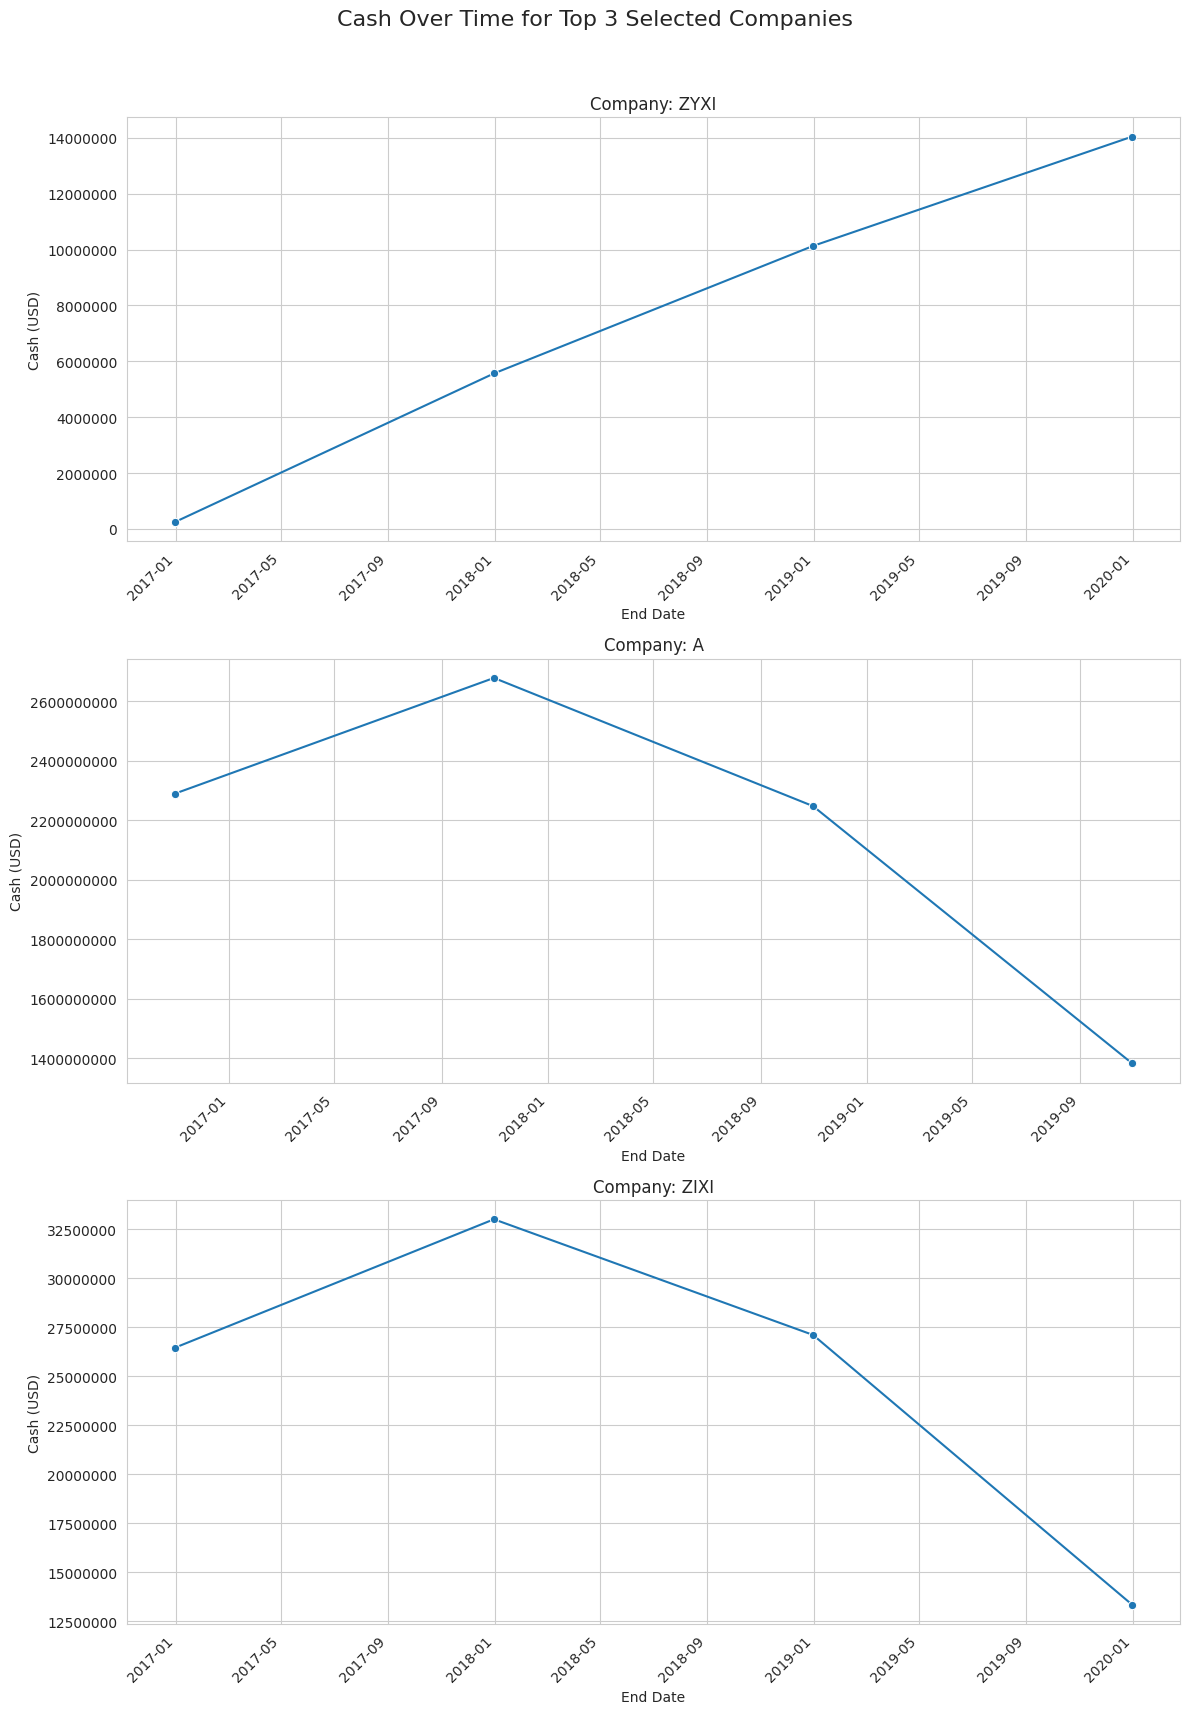

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que endDate sea datetime (ya hecho en Paso 3)
# df_selected_companies['endDate'] = pd.to_datetime(df_selected_companies['endDate'])

# Seleccionar las 3 empresas elegidas (ya hecho en Paso 3)
# top_3_stocks = ['ZYXI', 'A', 'ZIXI'] # Reemplazar con las empresas seleccionadas

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

# Crear una figura con 3 subplots (3 filas, 1 columna)
fig, axes = plt.subplots(nrows=len(top_3_stocks), ncols=1, figsize=(12, 18), sharex=False)
fig.suptitle('Cash Over Time for Top 3 Selected Companies', fontsize=16)

for i, stock in enumerate(top_3_stocks):
    # Filtrar datos para la empresa actual
    company_data = df_selected_companies[df_selected_companies['stock'] == stock].copy()

    # Crear el gráfico en el subplot correspondiente
    ax = axes[i]
    sns.lineplot(data=company_data, x='endDate', y='cash', marker='o', ax=ax)
    ax.set_title(f'Company: {stock}')
    ax.set_xlabel('End Date')
    ax.set_ylabel('Cash (USD)')
    ax.ticklabel_format(style='plain', axis='y') # Evitar notación científica en el eje Y
    ax.grid(True)

    # Formato de las fechas en el eje x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajustar el diseño para que el título no se superponga
plt.show()

In [17]:
# Paso 5 — División 80/20 (entrenamiento / prueba)

# Diccionario para almacenar los dataframes de entrenamiento y prueba por cada stock
train_data = {}
test_data = {}

# Usamos df_processed (que ya tiene la columna cash_lag_1 y ha manejado los NaNs)
for stock in top_3_stocks:
    # Filtrar datos para la empresa actual del DataFrame que ya tiene la lag feature
    company_data = df_processed[df_processed['stock'] == stock].copy()

    # Calcular el índice para la división 80/20
    split_index = int(len(company_data) * 0.8)

    # Dividir los datos
    train_data[stock] = company_data.iloc[:split_index].copy()
    test_data[stock] = company_data.iloc[split_index:].copy()

    print(f"\nStock: {stock}")
    print(f"  Training data size: {len(train_data[stock])} rows")
    print(f"  Test data size: {len(test_data[stock])} rows")
    print(f"  Training data date range: {train_data[stock]['endDate'].min().strftime('%Y-%m-%d')} to {train_data[stock]['endDate'].max().strftime('%Y-%m-%d')}")
    print(f"  Test data date range: {test_data[stock]['endDate'].min().strftime('%Y-%m-%d')} to {test_data[stock]['endDate'].max().strftime('%Y-%m-%d')}")


Stock: ZYXI
  Training data size: 2 rows
  Test data size: 1 rows
  Training data date range: 2017-12-31 to 2018-12-31
  Test data date range: 2019-12-31 to 2019-12-31

Stock: A
  Training data size: 2 rows
  Test data size: 1 rows
  Training data date range: 2017-10-31 to 2018-10-31
  Test data date range: 2019-10-31 to 2019-10-31

Stock: AA
  Training data size: 2 rows
  Test data size: 1 rows
  Training data date range: 2017-12-31 to 2018-12-31
  Test data date range: 2019-12-31 to 2019-12-31


# Paso 6 — crea y entrena el modelo de regresión lineal para predecir `cash` por empresa

Objetivo: entrenar un modelo de regresión lineal por cada `stock` usando la serie temporal (respetando orden temporal) y evaluar en el 20% final.

Pasos recomendados:
- Preprocesamiento
    - Definir variables para el entrenamiento: y = `cash` (variable objetivo). `data` → X (conjunto de características a usar para predecir `cash`, p. ej. rezagos de `cash`, indicadores temporales, variables exógenas). Usar X e y en el entrenamiento: `model.fit(X_train, y_train)`.
    - Asegurar `endDate` como datetime y ordenar por `stock`, `endDate`.  - Asegurar `endDate` como datetime y ordenar por `stock`, `endDate`.



In [18]:
from sklearn.linear_model import LinearRegression
import pandas as pd # Import pandas if not already imported in this cell

# Diccionario para almacenar los modelos entrenados por cada stock
models = {}

# Diccionario para almacenar los datos de prueba (X_test, y_test) para cada stock
# Esto es útil para la evaluación posterior
prepared_test_data = {}

for stock in top_3_stocks:
    # Preparar datos de entrenamiento
    # X_train ahora incluirá endDate (ordinal) y cash_lag_1
    X_train_date = train_data[stock]['endDate'].apply(lambda date: date.toordinal())
    X_train_lag = train_data[stock]['cash_lag_1']
    X_train = pd.concat([X_train_date, X_train_lag], axis=1).values # Combinar en un array 2D
    y_train = train_data[stock]['cash'].values

    # Preparar datos de prueba para su uso posterior
    # X_test ahora incluirá endDate (ordinal) y cash_lag_1
    X_test_date = test_data[stock]['endDate'].apply(lambda date: date.toordinal())
    X_test_lag = test_data[stock]['cash_lag_1']
    X_test = pd.concat([X_test_date, X_test_lag], axis=1).values # Combinar en un array 2D
    y_test = test_data[stock]['cash'].values
    prepared_test_data[stock] = {'X_test': X_test, 'y_test': y_test}

    # Inicializar y entrenar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Almacenar el modelo entrenado
    models[stock] = model

    print(f"Modelo de Regresión Lineal entrenado para {stock}.")
    print(f"  Coeficientes (slope): {model.coef_}") # Coeficientes para ambas features
    print(f"  Intercepto: {model.intercept_:.2f}\n")

Modelo de Regresión Lineal entrenado para ZYXI.
  Coeficientes (slope): [5.8890693e-05 8.5802933e-01]
  Intercepto: 5353023.37

Modelo de Regresión Lineal entrenado para A.
  Coeficientes (slope): [-1.03961116e-06 -1.10796915e+00]
  Intercepto: 5214141388.94

Modelo de Regresión Lineal entrenado para AA.
  Coeficientes (slope): [-3.50651897e-07 -4.85148515e-01]
  Intercepto: 1771831683.43



In [ ]:
#codigo aqui

# Paso 7 — Verifica tu modelo de regresión lineal: grafica real vs predicho para las 3 empresas

- Objetivo: comparar visualmente los valores reales de `cash` del conjunto de prueba con los valores predichos por el modelo para cada una de las 3 empresas seleccionadas.
- Requisitos: tener `endDate` como datetime, el conjunto test por cada `stock`, y las predicciones (`y_pred`) para cada test.
- Pasos recomendados:
    - Para cada empresa (stock):
        - Extraer test: filas finales (20%) ordenadas por `endDate`.
        - Obtener predicciones usando el modelo entrenado: `y_pred = model.predict(X_test)`.
        - Crear una gráfica con `endDate` en el eje x y ambos: `cash` real (línea/points) y `cash` predicho (línea punteada) en el eje y.
        - Añadir título con el ticker, leyenda, etiquetas de ejes y grid. Formatear fechas y rotar etiquetas si hace falta.
    - Opcional: mostrar las 3 series en subplots (3 filas x 1 columna) para facilitar comparación.
    - Calcular y mostrar métricas de error por empresa (MAE, RMSE, R2) bajo cada gráfico o en una tabla resumen.
- Resultado esperado: tres gráficas (una por empresa) mostrando real vs predicho y una tabla o texto con las métricas de evaluación.

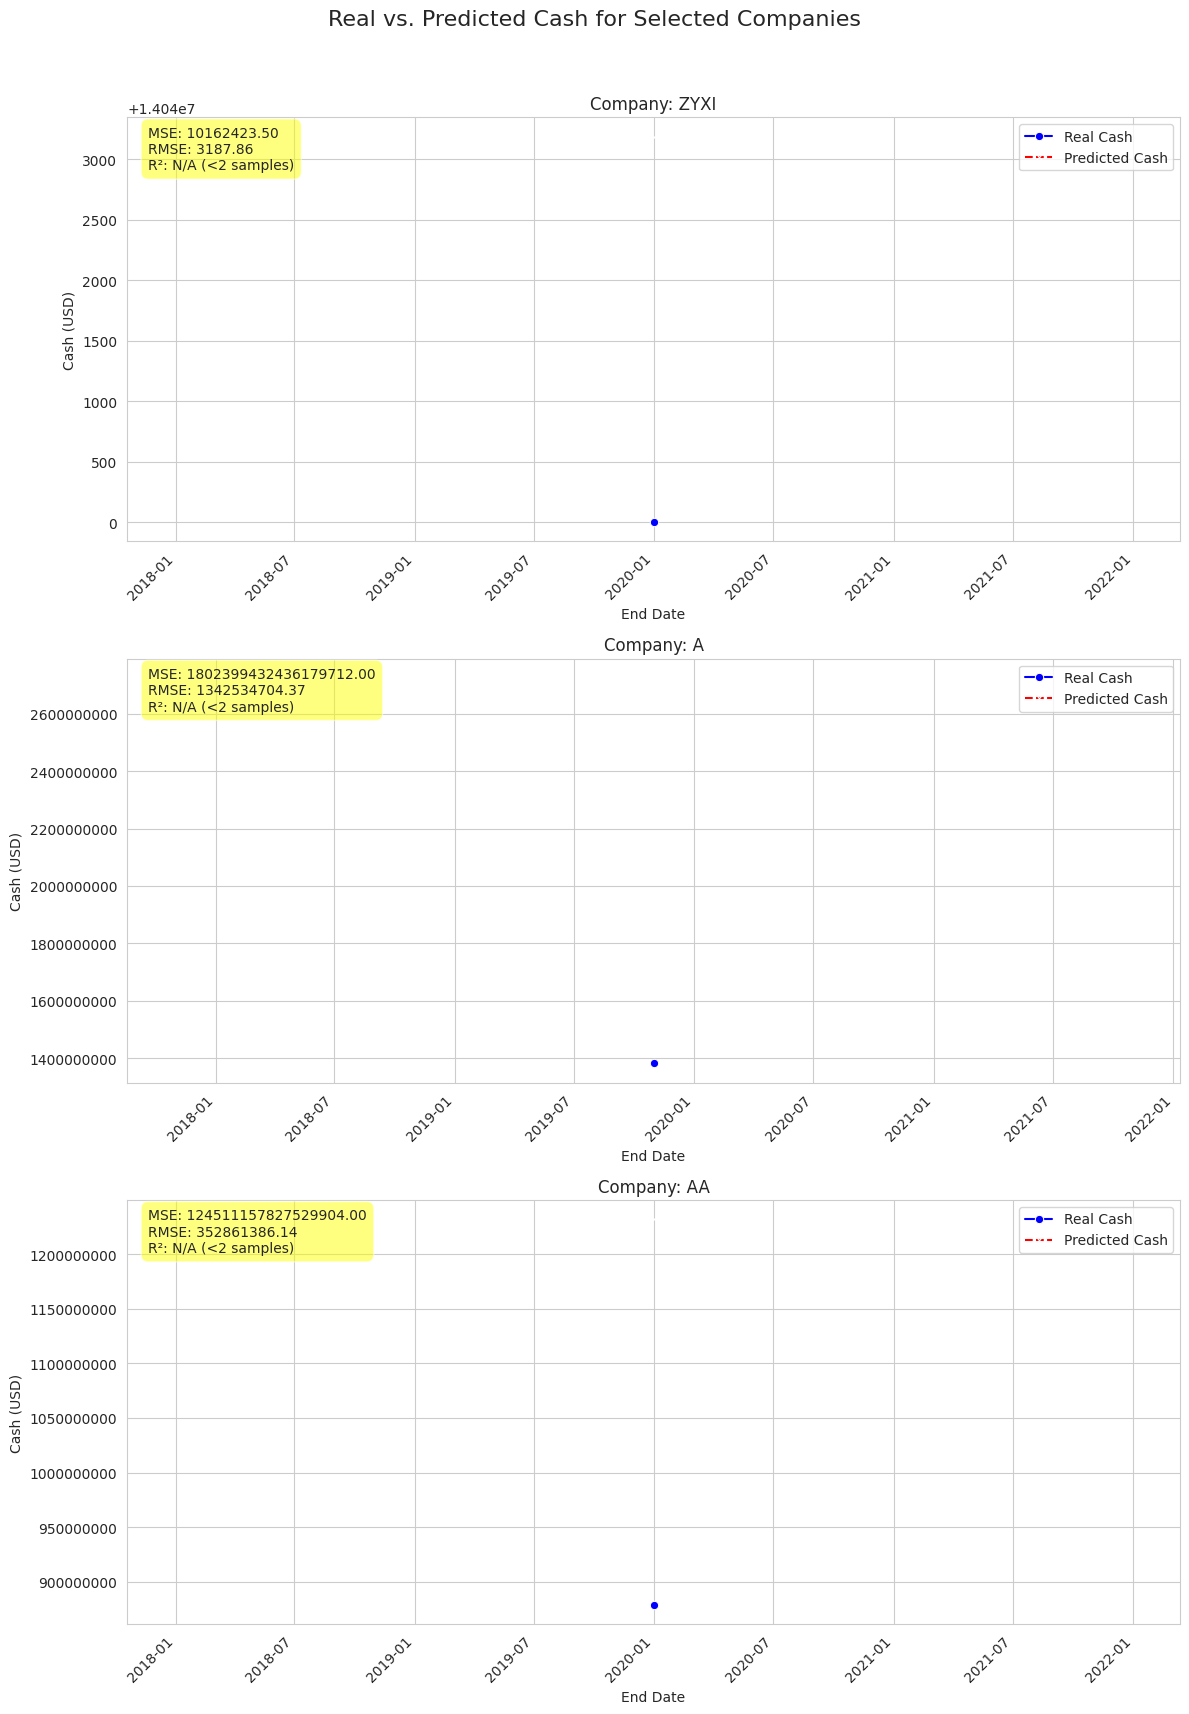

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Configurar el estilo de los gráficos
sns.set_style('whitegrid')

# Crear una figura con 3 subplots (3 filas, 1 columna)
fig, axes = plt.subplots(nrows=len(top_3_stocks), ncols=1, figsize=(12, 18), sharex=False)
fig.suptitle('Real vs. Predicted Cash for Selected Companies', fontsize=16)

for i, stock in enumerate(top_3_stocks):
    # Obtener los datos de prueba y el modelo para el stock actual
    X_test = prepared_test_data[stock]['X_test']
    y_test = prepared_test_data[stock]['y_test']
    model = models[stock]

    # Realizar predicciones
    y_pred = model.predict(X_test)

    # Convertir X_test de ordinal a datetime para el eje x
    # Asegurarse de que el DataFrame test_data[stock] sea consistente
    dates_test = test_data[stock]['endDate'] # Usar las fechas originales del test_data

    # Crear el gráfico en el subplot correspondiente
    ax = axes[i]
    sns.lineplot(x=dates_test, y=y_test, marker='o', label='Real Cash', ax=ax, color='blue')
    sns.lineplot(x=dates_test, y=y_pred, marker='x', linestyle='--', label='Predicted Cash', ax=ax, color='red')

    ax.set_title(f'Company: {stock}')
    ax.set_xlabel('End Date')
    ax.set_ylabel('Cash (USD)')
    ax.ticklabel_format(style='plain', axis='y') # Evitar notación científica en el eje Y
    ax.grid(True)
    ax.legend()

    # Formato de las fechas en el eje x
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Calcular y mostrar métricas de error
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Conditionally calculate R² if there are enough samples
    if len(y_test) < 2:
        r2_display = 'N/A (<2 samples)'
    else:
        r2 = r2_score(y_test, y_pred)
        r2_display = f'{r2:.2f}'

    ax.text(0.02, 0.98, f'MSE: {mse:.2f}\nRMSE: {rmse:.2f}\nR²: {r2_display}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajustar el diseño para que el título no se superponga
plt.show()

In [ ]:
#codigo aqui

In [20]:
from sklearn.metrics import mean_absolute_error

print("\nMétricas de Evaluación del Modelo (MAE):\n")
for stock in top_3_stocks:
    X_test = prepared_test_data[stock]['X_test']
    y_test = prepared_test_data[stock]['y_test']
    model = models[stock]

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    print(f"Empresa: {stock}")
    print(f"  MAE: {mae:.2f}\n")


Métricas de Evaluación del Modelo (MAE):

Empresa: ZYXI
  MAE: 3187.86

Empresa: A
  MAE: 1342534704.37

Empresa: AA
  MAE: 352861386.14



# Paso 8 — Verificación de modelos (MSE, RMSE, R2)

Instrucciones breves:
- Asegúrese de tener para cada empresa: y_test (valores reales) y y_pred (predicciones).
- Calcular métricas con sklearn: mean_squared_error(y_test, y_pred), RMSE = sqrt(MSE), r2_score(y_test, y_pred).
- Presentar los resultados en una tabla por empresa y añadir una conclusión corta.

Empresa 1 (ticker: AAA)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Empresa 2 (ticker: BBB)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Empresa 3 (ticker: CCC)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Pequeña conclusión:
- Comparar RMSE/MSE absolutos para evaluar error en unidades de `cash`; RMSE más bajo = mejor precisión.
- R2 indica proporción de varianza explicada (cercano a 1 → buen ajuste; cercano a 0 o negativo → mal ajuste).
- Si alguno de los modelos muestra RMSE alto o R2 bajo, considerar: más features (rezagos, variables temporales), regularización, transformación de la serie o modelos no lineales.

In [ ]:
#codigo aqui

## Preguntas de Analisis

1. ¿Qué variables (features) usaste para predecir `cash` y por qué crees que son relevantes?
2. ¿Cómo realizaste la división temporal 80/20 por empresa y por qué es importante no barajar (shuffle) los datos en series temporales?
3. ¿Cuál es la diferencia entre MSE y RMSE y qué nos dice cada métrica sobre la precisión de las predicciones?
4. ¿Qué interpreta el valor de R² en este problema (predicción de `cash`) y qué limitaciones tiene su interpretación en series temporales?
5. Si obtienes un RMSE alto o un R² bajo, ¿qué acciones concretas propondrías para mejorar el modelo (p. ej. features, rezagos, transformaciones, modelos alternativos)?